In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import pmdarima as pm
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import ta

Loading the data and getting familiar with it.

In [56]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Data preprocessing

In [ ]:
# Filling missing dates with the previous day's values
first_date = df['Date'].min()
last_date = df['Date'].max()

# Find missing values in the data
missing_values = df.isnull().sum()
print("Missing values in each column:") 
print(missing_values)

# Fill missing values with previous day's values
df.fillna(method='ffill', inplace=True)

series = df["Open"]

# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

Missing values in each column:
Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


C:\Users\eknut\AppData\Local\Temp\ipykernel_9164\2037005637.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Extracting trend, seasonality and residuals from the time series data.

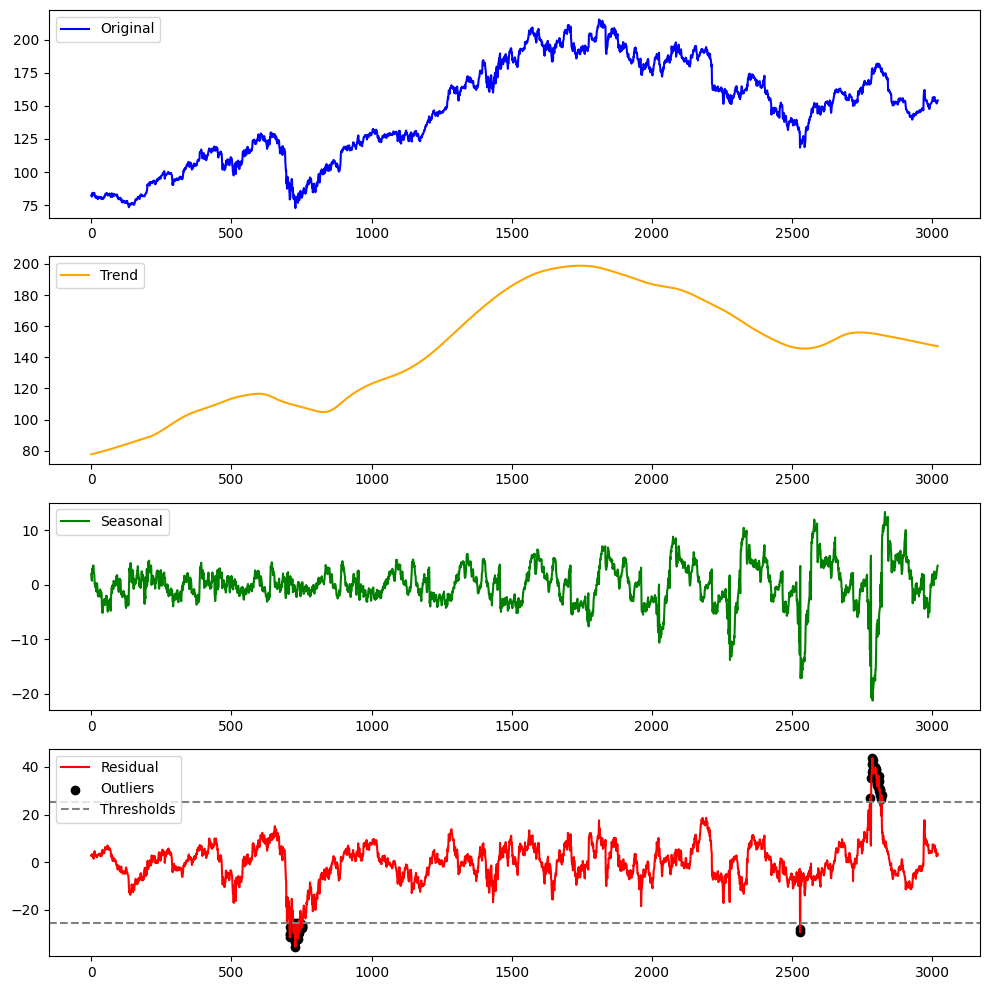

Number of outliers found: 68
Threshold: +/- 25.3331


In [58]:
# use indexes instead of dates for STL decomposition
indexes = pd.RangeIndex(start=0, stop=len(df), step=1)

stl = STL(series, period=252, seasonal=13, robust=True)

res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

# Find outliers in the residuals using Z-score method
mu = resid.mean()
sigma = resid.std()
threshold = 3 * sigma

# Find Outliers
outliers = resid[np.abs(resid) > threshold]

plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(indexes, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(indexes, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(indexes, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(indexes, resid, label='Residual', color='red')
plt.scatter(indexes[outliers.index], outliers, color='black', label='Outliers')
plt.axhline(y=threshold, color='gray', linestyle='--', label='Thresholds')
plt.axhline(y=-threshold, color='gray', linestyle='--')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Number of outliers found: {len(outliers)}")
print(f"Threshold: +/- {threshold:.4f}")

Plotting raw data for opening prices and volumes.

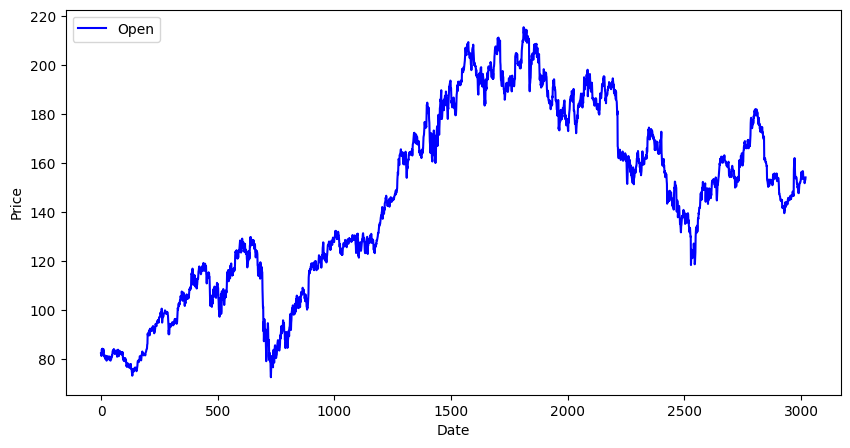

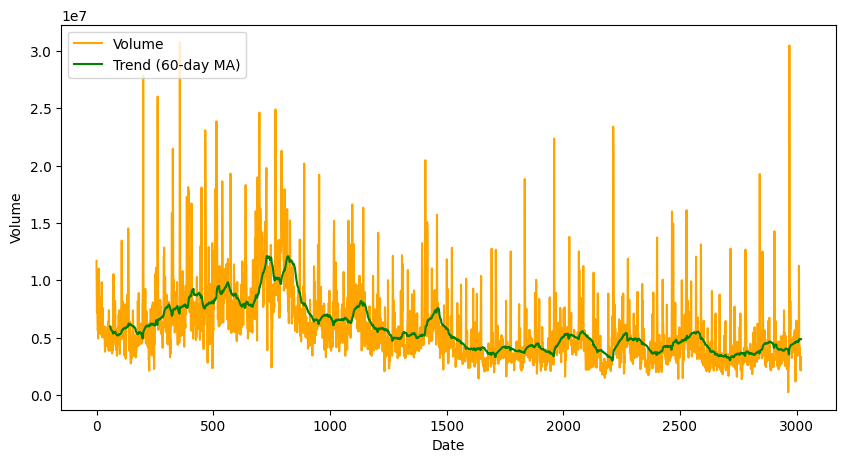

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(indexes, series, label='Open', color='blue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(indexes, df['Volume'][series.index], label='Volume', color='orange')
trend_volume = df['Volume'][series.index].rolling(window=60).mean()
plt.plot(indexes, trend_volume, label='Trend (60-day MA)', color='green')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(loc='upper left')
plt.show()

Autocorrelation analysis

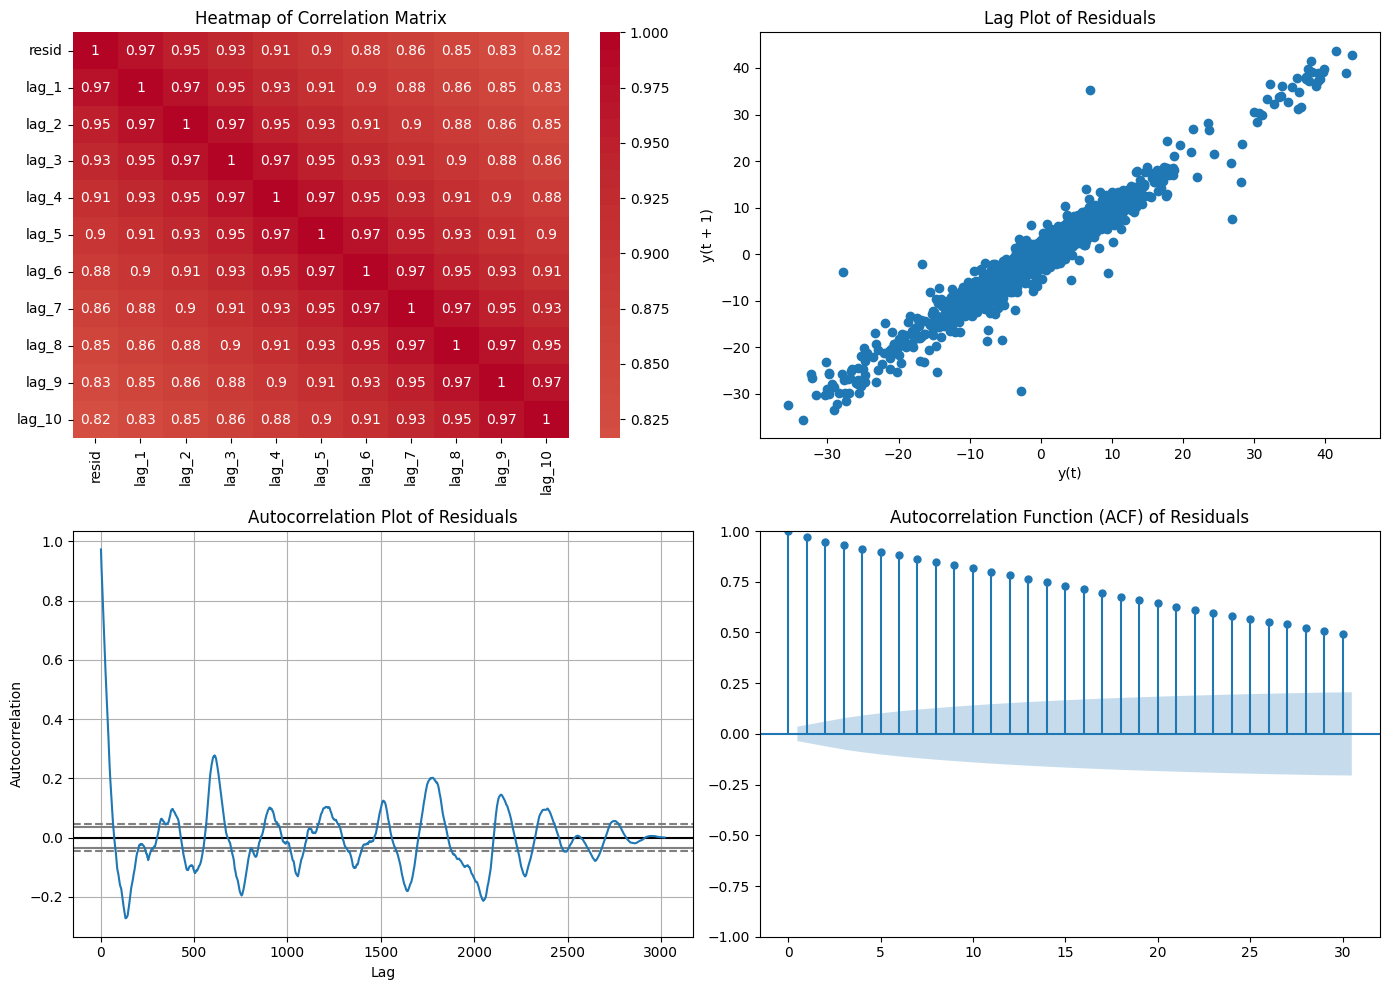

In [60]:
# Create a 1-10 day lagged dataset of the residuals
lagged_resid = pd.DataFrame({'resid': resid})
for i in range(1, 11):
    lagged_resid[f'lag_{i}'] = lagged_resid['resid'].shift(i)
lagged_resid = lagged_resid.dropna()

# Compute the correlation matrix
corr = lagged_resid.corr()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix')

# Lag plot
pd.plotting.lag_plot(resid, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Residuals')

# Autocorrelation plot
pd.plotting.autocorrelation_plot(resid, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Residuals')

# ACF (from statsmodels)
plot_acf(resid, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Residuals')

plt.tight_layout()
plt.show()

Analyze returns

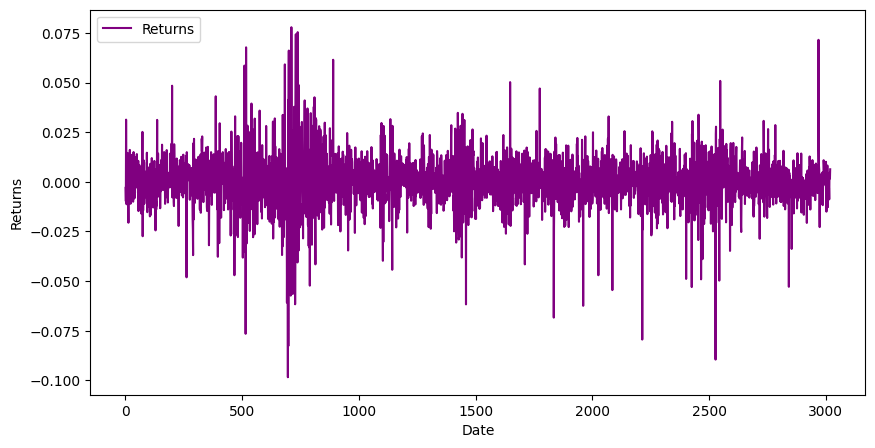

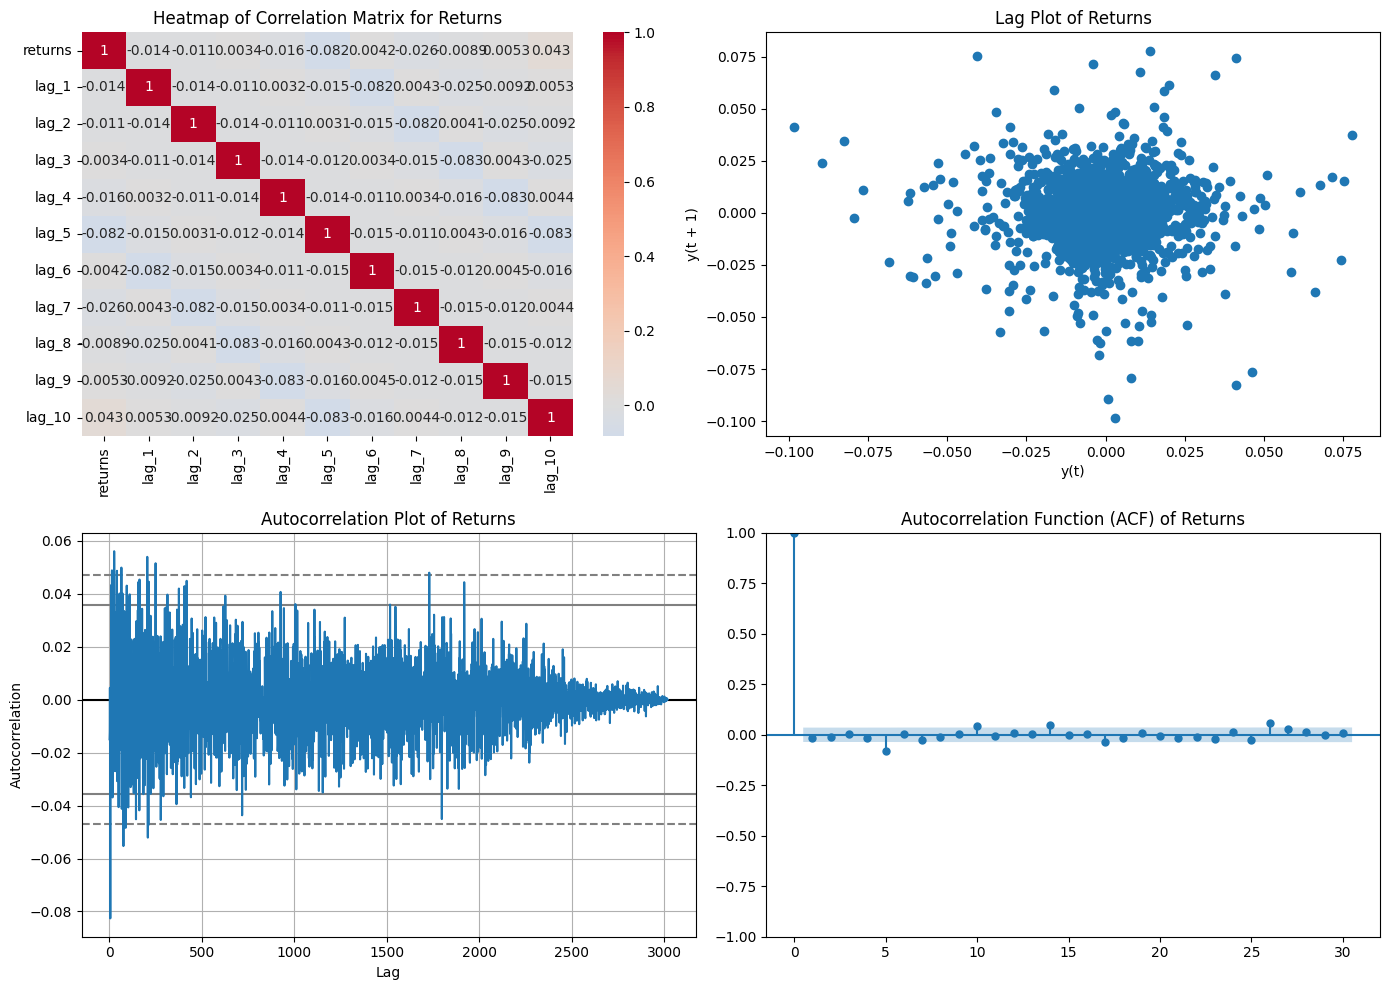

In [61]:
# Calculate returns
returns = series.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.plot(indexes[1:], returns, label='Returns', color='purple')
# plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Autocorrelation of returns
# Create a 1-10 day lagged dataset
lagged_returns = pd.DataFrame({'returns': returns})
for i in range(1, 11):
    lagged_returns[f'lag_{i}'] = lagged_returns['returns'].shift(i)
lagged_returns = lagged_returns.dropna()

# Compute the correlation matrix
corr_returns = lagged_returns.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Heatmap
sns.heatmap(corr_returns, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix for Returns')
# Lag plot
pd.plotting.lag_plot(returns, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Returns')
# Autocorrelation plot
pd.plotting.autocorrelation_plot(returns, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Returns')
# ACF (from statsmodels)
plot_acf(returns, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Returns')
plt.tight_layout()
plt.show()

## ARIMA Model

Forecasting of the prices

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=9740.501, Time=1.19 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9745.277, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9742.056, Time=0.26 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=9742.584, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9743.952, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=9742.173, Time=0.45 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=9740.101, Time=1.64 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=9740.239, Time=0.94 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=9741.194, Time=2.70 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=9741.092, Time=3.40 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=9739.573, Time=2.06 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=9740.413, Time=0.53 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=9740.404, Time=0.45 sec
 ARIMA(2,1,1)(0,0,2)[7] intercept   : AIC=9744.045, Time=1.03 sec
 ARIMA(1,1,2)(0,0,2)[7] intercept

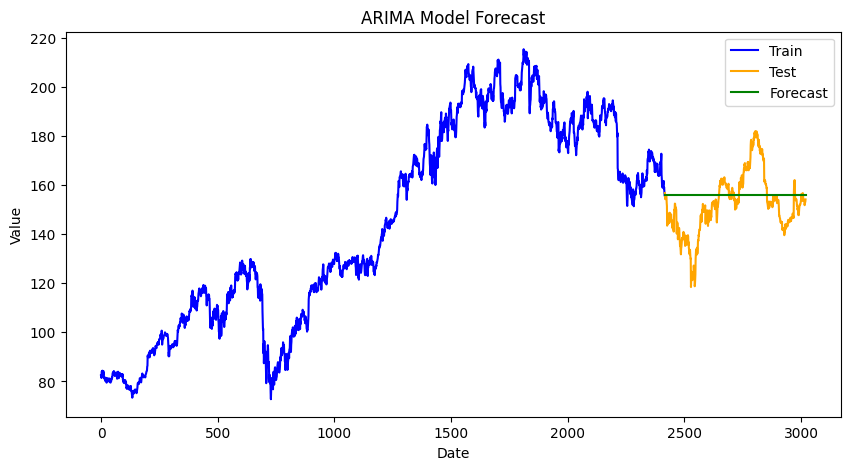

RMSE: 12.861992097979096
MAE: 10.079735099337743
R2 Score: -0.08721794410302719


In [62]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

auto_model = pm.auto_arima(train,
                           start_p=1, start_q=1,
                           test='adf',       # Use 'adf' test to find the optimal 'd'
                           max_p=5, max_q=5, # Maximum p and q
                           m=7,              # Seasonality
                           d=None,           # Let the test determine 'd'
                           seasonal=True,    # Seasonality
                           start_P=0,
                           D=0,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

# Best order
best_order = auto_model.order
print(f"Best Order: {best_order}")

# Fit ARIMA model
model = ARIMA(train, order=best_order)
model_fit = model.fit()
# Forecast
forecast = model_fit.forecast(steps=len(test))
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score
rmse = root_mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

Forecasting of the STL residuals

Best Order for Residuals: (1, 0, 1)
Best Order for Trend: (2, 1, 3)


c:\Users\eknut\Documents\Koodit\Kurssit\adaml\stock-market-forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


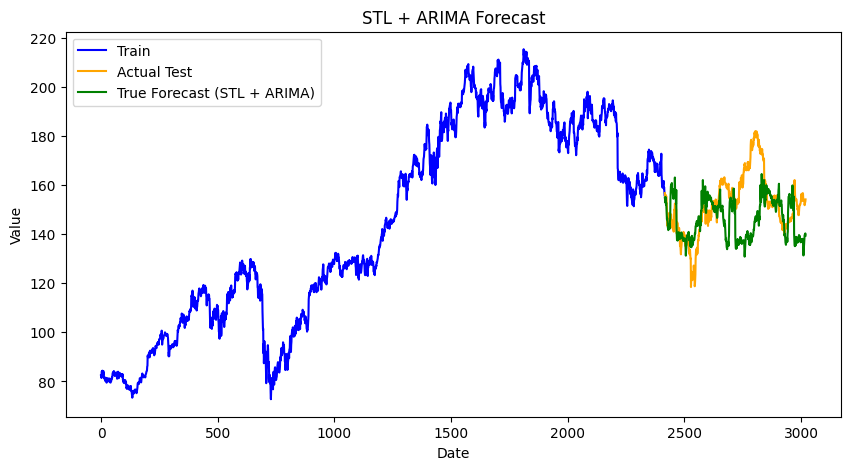

RMSE (Hybrid): 15.158222197143004
MAE (Hybrid): 11.288690341369321
R2 Score (Hybrid): -0.5100685844337602


In [63]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Original series splits
train_series, test_series = series[:train_size], series[train_size:]

period = 252
seasonal = 13
stl_train = STL(train_series, period=period, seasonal=seasonal, robust=True)
res_train = stl_train.fit()
n_periods = len(test_series)

# ARIMA on Residuals
auto_model_resid = pm.auto_arima(res_train.resid,
                                 start_p=1, start_q=1,
                                 test='adf',
                                 max_p=5, max_q=5,
                                 m=7, seasonal=True,
                                 d=None, D=0,
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_resid = auto_model_resid.order
print(f"Best Order for Residuals: {best_order_resid}")

model_resid = ARIMA(res_train.resid, order=best_order_resid)
model_resid_fit = model_resid.fit()

resid_forecast = pd.Series(model_resid_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# ARIMA on Trend
auto_model_trend = pm.auto_arima(res_train.trend,
                                 start_p=1, start_q=1,
                                 d=1,
                                 max_p=3, max_q=3,
                                 seasonal=False, # No seasonality in the trend
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_trend = auto_model_trend.order
print(f"Best Order for Trend: {best_order_trend}")

model_trend = ARIMA(res_train.trend, order=best_order_trend)
model_trend_fit = model_trend.fit()

trend_forecast = pd.Series(model_trend_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# Seasonal Forecasting by repeating the last observed seasonal cycle
last_season = res_train.seasonal[-period:]
num_reps = int(np.ceil(n_periods / period))
seasonal_forecast_tiled = np.tile(last_season, num_reps)
# Trim to the exact length of the test set
seasonal_forecast = pd.Series(seasonal_forecast_tiled[:n_periods], 
                                index=test_series.index)

# Combine forecasts
total_forecast = trend_forecast + seasonal_forecast + resid_forecast

# --- 6. Plot Results ---
plt.figure(figsize=(10, 5))
plt.plot(train_series, label='Train', color='blue')
plt.plot(test_series, label='Actual Test', color='orange')
plt.plot(total_forecast, label='True Forecast (STL + ARIMA)', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('STL + ARIMA Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score for the hybrid model
rmse_hybrid = root_mean_squared_error(test_series, total_forecast)
mae_hybrid = mean_absolute_error(test_series, total_forecast)
r2_hybrid = r2_score(test_series, total_forecast)

print(f"RMSE (Hybrid): {rmse_hybrid}")
print(f"MAE (Hybrid): {mae_hybrid}")
print(f"R2 Score (Hybrid): {r2_hybrid}")

## RNN and LSTM Models

In [64]:
# RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc_layers(out[:, -1, :])
        return out
    
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc_layers(out[:, -1, :])
        return out

In [65]:
# Create training, validation, and testing datasets
def get_train_val_test(data_X, data_y, n_past, n_future):
    X, y = [], []
    for i in range(len(data_X) - n_past - n_future + 1):
        X.append(data_X[i : i + n_past])
        y.append(data_y[i + n_past : i + n_past + n_future])
        
    X = np.array(X)
    y = np.array(y)    
        
    X_test = X[-1:]
    y_test = y[-1:]

    X_remaining = X[:-1]
    y_remaining = y[:-1]
    # Split remaining data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_remaining, y_remaining, 
        test_size=0.2,   
        shuffle=False    
    )
    return X_train, y_train, X_val, y_val, X_test, y_test


y = df["Open"]

# Ensure indices are sorted
df = df.sort_values('Date').reset_index(drop=True)

# Momentum: RSI (Relative Strength Index)
rsi_indicator = ta.momentum.RSIIndicator(close=df["Close"], window=14)
df["RSI_14"] = rsi_indicator.rsi()

# Volatility: Bollinger Bands
bb_indicator = ta.volatility.BollingerBands(close=df["Close"], window=20, window_dev=2)
# Band Width = (Upper - Lower) / Mid
df["BB_Width"] = (bb_indicator.bollinger_hband() - bb_indicator.bollinger_lband()) / bb_indicator.bollinger_mavg()

# Volatility: ATR (Average True Range)
atr_indicator = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["Close"], window=14)
df["ATR_14"] = atr_indicator.average_true_range()

# Trend: SMA (Simple Moving Average) & Distance
sma_indicator = ta.trend.SMAIndicator(close=df["Close"], window=50)
df["SMA_50"] = sma_indicator.sma_indicator()

# Distance from SMA (Stationary Feature)
df["Dist_SMA_50"] = (df["Close"] - df["SMA_50"]) / df["SMA_50"]

# Volume: OBV (On-Balance Volume)
obv_indicator = ta.volume.OnBalanceVolumeIndicator(close=df["Close"], volume=df["Volume"])
df["OBV"] = obv_indicator.on_balance_volume()

# Drop NaN values generated by the windowing
df.dropna(inplace=True)

# Change date column to features
df["Date"] = pd.to_datetime(df["Date"])
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Change cyclical features to sin and cos components
df['Day_Sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_Cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Drop unnecessary columns
X = df.drop(columns=["Date", "Open", "Name", "DayOfWeek", "Month"])
n_features = X.shape[1]
non_cyclical_idx = [i for i, col in enumerate(X.columns) if col in ['High', 'Low', 'Close', 'Volume', 'Year']]
print(X.head())

# Create sequences
n_past = 63 # Use past 63 days (approx. 3 months of trading days)
n_future_5 = 5 # Predict next trading week
n_future_21 = 21 # Predict next trading month

X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5 = get_train_val_test(X.values, y, n_past, n_future_5)
X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21 = get_train_val_test(X.values, y, n_past, n_future_21)

# Normalize data with StandardScaler and only on non-cyclical features
scaler_X_5 = StandardScaler()
scaler_X_21 = StandardScaler()
scaler_y_5 = StandardScaler()
scaler_y_21 = StandardScaler()

# Fit scalers on training data
scaler_X_5.fit(X_train_5[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx)))
scaler_y_5.fit(y_train_5.reshape(-1, 1))

scaler_X_21.fit(X_train_21[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx)))
scaler_y_21.fit(y_train_21.reshape(-1, 1))

# Normalize 5 day dataset
for dataset in [(X_train_5, y_train_5), (X_val_5, y_val_5), (X_test_5, y_test_5)]:
    X_data, y_data = dataset
    # Normalize X
    X_data[:, :, non_cyclical_idx] = scaler_X_5.transform(
        X_data[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx))).reshape(X_data.shape[0], X_data.shape[1], len(non_cyclical_idx)
    )
    # Normalize y
    y_data[:] = scaler_y_5.transform(y_data.reshape(-1, 1)).reshape(y_data.shape)
    
# Normalize 21 day dataset    
for dataset in [(X_train_21, y_train_21), (X_val_21, y_val_21), (X_test_21, y_test_21)]:
    X_data, y_data = dataset
    # Normalize X
    X_data[:, :, non_cyclical_idx] = scaler_X_21.transform(
        X_data[:, :, non_cyclical_idx].reshape(-1, len(non_cyclical_idx))).reshape(X_data.shape[0], X_data.shape[1], len(non_cyclical_idx)
    )
    # Normalize y
    y_data[:] = scaler_y_21.transform(y_data.reshape(-1, 1)).reshape(y_data.shape)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Create DataLoaders
batch_size = 64
train_dataset_5 = TensorDataset(torch.tensor(X_train_5, dtype=torch.float32), torch.tensor(y_train_5, dtype=torch.float32).to(device))
train_loader_5 = DataLoader(train_dataset_5, batch_size=batch_size, shuffle=True)
val_dataset_5 = TensorDataset(torch.tensor(X_val_5, dtype=torch.float32), torch.tensor(y_val_5, dtype=torch.float32).to(device))
val_loader_5 = DataLoader(val_dataset_5, batch_size=batch_size, shuffle=False)
test_dataset_5 = TensorDataset(torch.tensor(X_test_5, dtype=torch.float32), torch.tensor(y_test_5, dtype=torch.float32).to(device))
test_loader_5 = DataLoader(test_dataset_5, batch_size=1, shuffle=False)


train_dataset_21 = TensorDataset(torch.tensor(X_train_21, dtype=torch.float32), torch.tensor(y_train_21, dtype=torch.float32).to(device))
train_loader_21 = DataLoader(train_dataset_21, batch_size=batch_size, shuffle=True)
val_dataset_21 = TensorDataset(torch.tensor(X_val_21, dtype=torch.float32), torch.tensor(y_val_21, dtype=torch.float32).to(device))
val_loader_21 = DataLoader(val_dataset_21, batch_size=batch_size, shuffle=False)
test_dataset_21 = TensorDataset(torch.tensor(X_test_21, dtype=torch.float32), torch.tensor(y_test_21, dtype=torch.float32).to(device))
test_loader_21 = DataLoader(test_dataset_21, batch_size=1, shuffle=False)


     High    Low  Close   Volume     RSI_14  BB_Width    ATR_14   SMA_50  \
49  83.76  82.64  83.38  5370400  68.417285  0.046485  1.134735  81.4796   
50  83.72  82.61  82.87  4299500  63.018564  0.051148  1.132968  81.4958   
51  83.41  82.82  83.30  6414500  65.491082  0.056834  1.094185  81.5228   
52  83.75  82.99  83.58  3870300  67.036558  0.062442  1.070315  81.5444   
53  84.99  83.58  83.81  7404300  68.292717  0.067447  1.094578  81.5216   

    Dist_SMA_50       OBV  Year   Day_Sin   Day_Cos  Month_Sin     Month_Cos  
49     0.023324   5638200  2006  0.974928 -0.222521        1.0  6.123234e-17  
50     0.016862   1338700  2006  0.433884 -0.900969        1.0  6.123234e-17  
51     0.021800   7753200  2006 -0.433884 -0.900969        1.0  6.123234e-17  
52     0.024963  11623500  2006  0.000000  1.000000        1.0  6.123234e-17  
53     0.028071  19027800  2006  0.781831  0.623490        1.0  6.123234e-17  
Using device: cuda


### Functions

In [66]:
# Training function
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, type):
    model.to(device)
    best_val_loss = float('inf')
    all_train_losses = []
    all_val_losses = []
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        val_losses = []
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        scheduler.step(avg_val_loss)
        
        # Save the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'best_model_{type}.pth')
    
        all_train_losses.append(avg_train_loss)
        all_val_losses.append(avg_val_loss)

    # Plot training and validation loss
    plt.figure(figsize=(10, 5))
    plt.plot(all_train_losses, label='Train Loss')
    plt.plot(all_val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

    # Load the best model
    model.load_state_dict(torch.load(f'best_model_{type}.pth'))
    return model

# Evaluation function
def evaluate_model(model, test_loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # ensure X is on device for inference
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            # move tensors to CPU before converting to numpy to avoid the cuda->numpy error
            predictions.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    # Inverse transform
    real_predictions = scaler_y.inverse_transform(predictions)
    real_actuals = scaler_y.inverse_transform(actuals)
    
    # Print evaluation metrics
    rmse = root_mean_squared_error(real_actuals, real_predictions)
    mae = mean_absolute_error(real_actuals, real_predictions)
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    
    return real_predictions, real_actuals

### RNN 

In [ ]:
# Train the RNN model on both 5-day and 21-day datasets
model_5 = RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_21 = RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_5 = torch.optim.Adam(model_5.parameters(), lr=1e-4)
optimizer_21 = torch.optim.Adam(model_21.parameters(), lr=1e-4)
scheduler_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_5, mode='min', factor=0.5, patience=10)
scheduler_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_21, mode='min', factor=0.5, patience=10)

# Train models
print("Training 5-day RNN model...")
model_5 = train_model(model_5, train_loader_5, val_loader_5, optimizer_5, criterion, scheduler_5, num_epochs, type='RNN 5-day')
print("Training 21-day RNN model...")
model_21 = train_model(model_21, train_loader_21, val_loader_21, optimizer_21, criterion, scheduler_21, num_epochs, type='RNN 21-day')

Evaluating 5-day RNN model...
Test RMSE: 5.2562
Test MAE: 5.2562
Evaluating 21-day RNN model...
Test RMSE: 3.8653
Test MAE: 3.8653


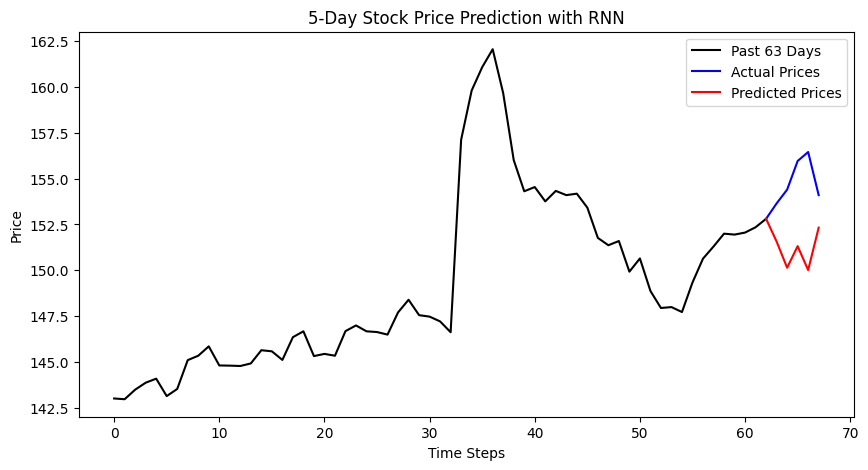

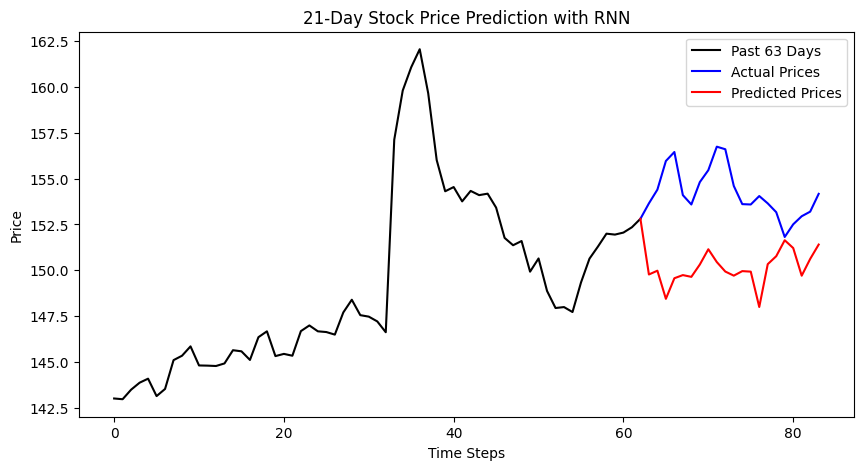

In [ ]:
# Evaluate models
print("Evaluating 5-day RNN model...")
simulated_prediction_5, y_test_5_real = evaluate_model(model_5, test_loader_5, scaler_y_5)
print("Evaluating 21-day RNN model...")
simulated_prediction_21, y_test_21_real = evaluate_model(model_21, test_loader_21, scaler_y_21)

past_data = y[-63-21:-21].values  
x_past = np.arange(0, len(past_data))

true_future_5_days_rnn = y.iloc[-21:-16].values 
true_future_21_days_rnn = y.iloc[-21:].values   

# 5-day prediction data
true_5d_rnn = true_future_5_days_rnn
pred_5d_rnn = simulated_prediction_5.flatten()
x_future_5d_rnn = np.arange(len(past_data) - 1, len(past_data) + len(true_5d_rnn))

true_5d_rnn = np.insert(true_5d_rnn, 0, past_data[-1])
pred_5d_rnn = np.insert(pred_5d_rnn, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_5d_rnn, true_5d_rnn, label='Actual Prices', color='blue')
plt.plot(x_future_5d_rnn, pred_5d_rnn, label='Predicted Prices', color='red')
plt.title('5-Day Stock Price Prediction with RNN')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

# 21-day prediction data
true_21d_rnn = true_future_21_days_rnn
pred_21d_rnn = simulated_prediction_21.flatten()
x_future_21d_rnn = np.arange(len(past_data) - 1, len(past_data) + len(true_21d_rnn))

true_21d_rnn = np.insert(true_21d_rnn, 0, past_data[-1])
pred_21d_rnn = np.insert(pred_21d_rnn, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_21d_rnn, true_21d_rnn, label='Actual Prices', color='blue')
plt.plot(x_future_21d_rnn, pred_21d_rnn, label='Predicted Prices', color='red')
plt.title('21-Day Stock Price Prediction with RNN')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

### LSTM Model

In [ ]:
# Train the LSTM model on both 5-day and 21-day datasets
model_lstm_5 = LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_lstm_21 = LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_lstm_5 = torch.optim.Adam(model_lstm_5.parameters(), lr=1e-4)
optimizer_lstm_21 = torch.optim.Adam(model_lstm_21.parameters(), lr=1e-4)
scheduler_lstm_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm_5, mode='min', factor=0.5, patience=10)
scheduler_lstm_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm_21, mode='min', factor=0.5, patience=10)

# Train models
print("Training 5-day LSTM model...")
model_lstm_5 = train_model(model_lstm_5, train_loader_5, val_loader_5, optimizer_lstm_5, criterion, scheduler_lstm_5, num_epochs, type='LSTM 5-day')
print("Training 21-day LSTM model...")
model_lstm_21 = train_model(model_lstm_21, train_loader_21, val_loader_21, optimizer_lstm_21, criterion, scheduler_lstm_21, num_epochs, type='LSTM 21-day')

Evaluating 5-day LSTM model...
Test RMSE: 5.8641
Test MAE: 5.8641
Evaluating 21-day LSTM model...
Test RMSE: 4.3792
Test MAE: 4.3792


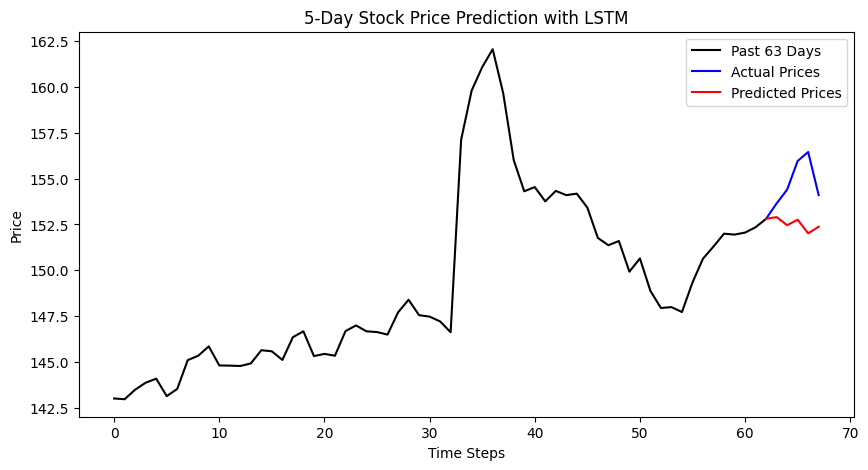

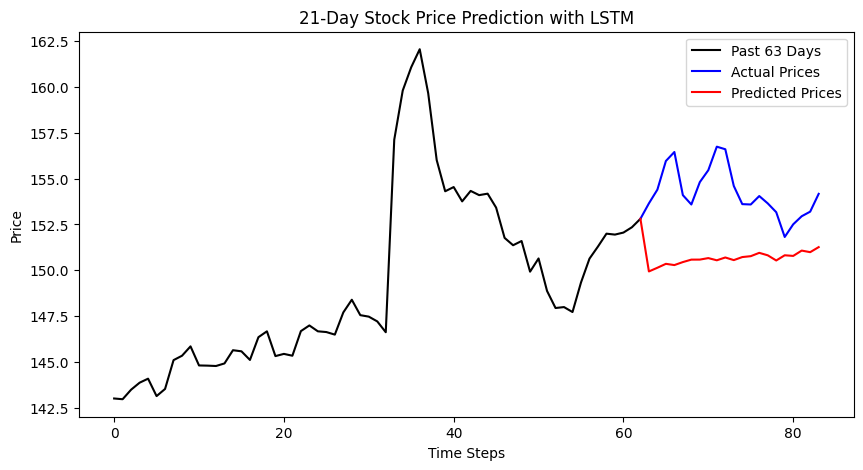

In [75]:
# Evaluate models
print("Evaluating 5-day LSTM model...")
simulated_prediction_lstm_5, y_test_lstm_5_real = evaluate_model(model_lstm_5, test_loader_5, scaler_y_5)
print("Evaluating 21-day LSTM model...")
simulated_prediction_lstm_21, y_test_lstm_21_real = evaluate_model(model_lstm_21, test_loader_21, scaler_y_21)

past_data = y[-63-21:-21].values  
x_past = np.arange(0, len(past_data))

true_future_5_days_lstm = y.iloc[-21:-16].values 
true_future_21_days_lstm = y.iloc[-21:].values   

# 5-day prediction data
true_5d_lstm = true_future_5_days_lstm
pred_5d_lstm = simulated_prediction_lstm_5.flatten()
x_future_5d_lstm = np.arange(len(past_data) - 1, len(past_data) + len(true_5d_lstm))

true_5d_lstm = np.insert(true_5d_lstm, 0, past_data[-1])
pred_5d_lstm = np.insert(pred_5d_lstm, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_5d_lstm, true_5d_lstm, label='Actual Prices', color='blue')
plt.plot(x_future_5d_lstm, pred_5d_lstm, label='Predicted Prices', color='red')
plt.title('5-Day Stock Price Prediction with LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

# 21-day prediction data
true_21d_lstm = true_future_21_days_lstm
pred_21d_lstm = simulated_prediction_lstm_21.flatten()
x_future_21d_lstm = np.arange(len(past_data) - 1, len(past_data) + len(true_21d_lstm))

true_21d_lstm = np.insert(true_21d_lstm, 0, past_data[-1])
pred_21d_lstm = np.insert(pred_21d_lstm, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_21d_lstm, true_21d_lstm, label='Actual Prices', color='blue')
plt.plot(x_future_21d_lstm, pred_21d_lstm, label='Predicted Prices', color='red')
plt.title('21-Day Stock Price Prediction with LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

# Transformer

Defining the model arhitecture

In [77]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, output_size, dropout=0.3):
        super(TransformerModel, self).__init__()
        self.input_linear = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, output_size)
        )

    def forward(self, x):
        x = self.input_linear(x)
        x = x.permute(1, 0, 2)  
        x = self.transformer_encoder(x)
        x = x.permute(1, 0, 2)  
        out = self.fc_layers(x[:, -1, :])  
        return out
    
# Initialize the models 
model_transformer_5 = TransformerModel(input_size=n_features, d_model=128, nhead=8, num_layers=2, dim_feedforward=512, output_size=n_future_5)
model_transformer_21 = TransformerModel(input_size=n_features, d_model=128, nhead=8, num_layers=2, dim_feedforward=512, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_transformer_5 = torch.optim.Adam(model_transformer_5.parameters(), lr=1e-4)
optimizer_transformer_21 = torch.optim.Adam(model_transformer_21.parameters(), lr=1e-4)
scheduler_transformer_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_5, mode='min', factor=0.5, patience=10)
scheduler_transformer_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_21, mode='min', factor=0.5, patience=10)

c:\Users\eknut\Documents\Koodit\Kurssit\adaml\stock-market-forecasting\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Normalizing all of the self-defined features correctly and initializing data loaders for transformer

In [80]:
all_features = X.columns.tolist()
cyclical_features = ['Day_Sin', 'Day_Cos', 'Month_Sin', 'Month_Cos']
non_cyclical_features = [col for col in all_features if col not in cyclical_features]
non_cyclical_idx_corrected = [i for i, col in enumerate(all_features) if col in non_cyclical_features]


def normalize_data_correctly(X_train, X_val, X_test, y_train, y_val, y_test, non_cyclical_indices):
    
    X_train_norm = X_train.copy()
    X_val_norm = X_val.copy() 
    X_test_norm = X_test.copy()
    
    
    for feature_idx in non_cyclical_indices:
    
        train_feature = X_train[:, :, feature_idx].flatten()
        scaler = StandardScaler()
        scaler.fit(train_feature.reshape(-1, 1))
        
    
        for X_data in [X_train_norm, X_val_norm, X_test_norm]:
            feature_data = X_data[:, :, feature_idx].flatten()
            normalized_data = scaler.transform(feature_data.reshape(-1, 1)).flatten()
            X_data[:, :, feature_idx] = normalized_data.reshape(X_data.shape[0], X_data.shape[1])
    
    y_scaler = StandardScaler()
    y_scaler.fit(y_train.reshape(-1, 1))
    
    y_train_norm = y_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
    y_val_norm = y_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
    y_test_norm = y_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
    
    return X_train_norm, X_val_norm, X_test_norm, y_train_norm, y_val_norm, y_test_norm, y_scaler

X_train_5_raw, y_train_5_raw, X_val_5_raw, y_val_5_raw, X_test_5_raw, y_test_5_raw = get_train_val_test(X.values, y.values, n_past, n_future_5)


X_train_5_corrected, X_val_5_corrected, X_test_5_corrected, y_train_5_corrected, y_val_5_corrected, y_test_5_corrected, y_scaler_5_corrected = normalize_data_correctly(
    X_train_5_raw, X_val_5_raw, X_test_5_raw, 
    y_train_5_raw, y_val_5_raw, y_test_5_raw, 
    non_cyclical_idx_corrected
)

train_dataset_5_corrected = TensorDataset(torch.tensor(X_train_5_corrected, dtype=torch.float32), torch.tensor(y_train_5_corrected, dtype=torch.float32))
train_loader_5_corrected = DataLoader(train_dataset_5_corrected, batch_size=batch_size, shuffle=True)

val_dataset_5_corrected = TensorDataset(torch.tensor(X_val_5_corrected, dtype=torch.float32), torch.tensor(y_val_5_corrected, dtype=torch.float32))
val_loader_5_corrected = DataLoader(val_dataset_5_corrected, batch_size=batch_size, shuffle=False)

test_dataset_5_corrected = TensorDataset(torch.tensor(X_test_5_corrected, dtype=torch.float32), torch.tensor(y_test_5_corrected, dtype=torch.float32))
test_loader_5_corrected = DataLoader(test_dataset_5_corrected, batch_size=1, shuffle=False)

In [81]:
X_train_21_raw, y_train_21_raw, X_val_21_raw, y_val_21_raw, X_test_21_raw, y_test_21_raw = get_train_val_test(X.values, y.values, n_past, n_future_21)

X_train_21_corrected, X_val_21_corrected, X_test_21_corrected, y_train_21_corrected, y_val_21_corrected, y_test_21_corrected, y_scaler_21_corrected = normalize_data_correctly(
    X_train_21_raw, X_val_21_raw, X_test_21_raw, 
    y_train_21_raw, y_val_21_raw, y_test_21_raw, 
    non_cyclical_idx_corrected
)

train_dataset_21_corrected = TensorDataset(torch.tensor(X_train_21_corrected, dtype=torch.float32), torch.tensor(y_train_21_corrected, dtype=torch.float32))
train_loader_21_corrected = DataLoader(train_dataset_21_corrected, batch_size=batch_size, shuffle=True)

val_dataset_21_corrected = TensorDataset(torch.tensor(X_val_21_corrected, dtype=torch.float32), torch.tensor(y_val_21_corrected, dtype=torch.float32))
val_loader_21_corrected = DataLoader(val_dataset_21_corrected, batch_size=batch_size, shuffle=False)

test_dataset_21_corrected = TensorDataset(torch.tensor(X_test_21_corrected, dtype=torch.float32), torch.tensor(y_test_21_corrected, dtype=torch.float32))
test_loader_21_corrected = DataLoader(test_dataset_21_corrected, batch_size=1, shuffle=False)

c:\Users\eknut\Documents\Koodit\Kurssit\adaml\stock-market-forecasting\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/100], Train Loss: 0.1620, Val Loss: 0.0542
Epoch [10/100], Train Loss: 0.0145, Val Loss: 0.0072
Epoch [10/100], Train Loss: 0.0145, Val Loss: 0.0072
Epoch [20/100], Train Loss: 0.0101, Val Loss: 0.0054
Epoch [20/100], Train Loss: 0.0101, Val Loss: 0.0054
Epoch [30/100], Train Loss: 0.0085, Val Loss: 0.0051
Epoch [30/100], Train Loss: 0.0085, Val Loss: 0.0051
Epoch [40/100], Train Loss: 0.0074, Val Loss: 0.0053
Epoch [40/100], Train Loss: 0.0074, Val Loss: 0.0053
Epoch [50/100], Train Loss: 0.0070, Val Loss: 0.0056
Epoch [50/100], Train Loss: 0.0070, Val Loss: 0.0056
Epoch [60/100], Train Loss: 0.0064, Val Loss: 0.0053
Epoch [60/100], Train Loss: 0.0064, Val Loss: 0.0053
Epoch [70/100], Train Loss: 0.0063, Val Loss: 0.0053
Epoch [70/100], Train Loss: 0.0063, Val Loss: 0.0053
Epoch [80/100], Train Loss: 0.0060, Val Loss: 0.0054
Epoch [80/100], Train Loss: 0.0060, Val Loss: 0.0054
Epoch [90/100], Train Loss: 0.0059, Val Loss: 0.0054
Epoch [90/100], Train Loss: 0.0059, Val Loss: 0

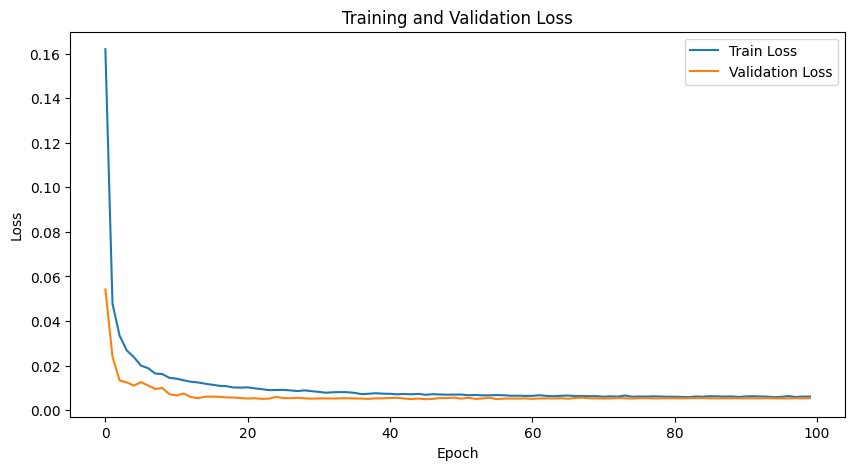

In [84]:
model_transformer_5_fixed = TransformerModel(
    input_size=n_features, 
    d_model=128, 
    nhead=8, 
    num_layers=2, 
    dim_feedforward=512, 
    output_size=n_future_5
)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_transformer_5_fixed = torch.optim.Adam(model_transformer_5_fixed.parameters(), lr=1e-4)
scheduler_transformer_5_fixed = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_5_fixed, mode='min', factor=0.5, patience=10)

model_transformer_5_fixed = train_model(
    model_transformer_5_fixed, 
    train_loader_5_corrected, 
    val_loader_5_corrected, 
    optimizer_transformer_5_fixed, 
    criterion, 
    scheduler_transformer_5_fixed, 
    num_epochs, 
    'Transformer_5_day'
)

Epoch [1/100], Train Loss: 0.2578, Val Loss: 0.1229
Epoch [10/100], Train Loss: 0.0170, Val Loss: 0.0066
Epoch [10/100], Train Loss: 0.0170, Val Loss: 0.0066
Epoch [20/100], Train Loss: 0.0118, Val Loss: 0.0062
Epoch [20/100], Train Loss: 0.0118, Val Loss: 0.0062
Epoch [30/100], Train Loss: 0.0097, Val Loss: 0.0057
Epoch [30/100], Train Loss: 0.0097, Val Loss: 0.0057
Epoch [40/100], Train Loss: 0.0086, Val Loss: 0.0058
Epoch [40/100], Train Loss: 0.0086, Val Loss: 0.0058
Epoch [50/100], Train Loss: 0.0077, Val Loss: 0.0051
Epoch [50/100], Train Loss: 0.0077, Val Loss: 0.0051
Epoch [60/100], Train Loss: 0.0073, Val Loss: 0.0054
Epoch [60/100], Train Loss: 0.0073, Val Loss: 0.0054
Epoch [70/100], Train Loss: 0.0069, Val Loss: 0.0053
Epoch [70/100], Train Loss: 0.0069, Val Loss: 0.0053
Epoch [80/100], Train Loss: 0.0067, Val Loss: 0.0053
Epoch [80/100], Train Loss: 0.0067, Val Loss: 0.0053
Epoch [90/100], Train Loss: 0.0068, Val Loss: 0.0052
Epoch [90/100], Train Loss: 0.0068, Val Loss: 0

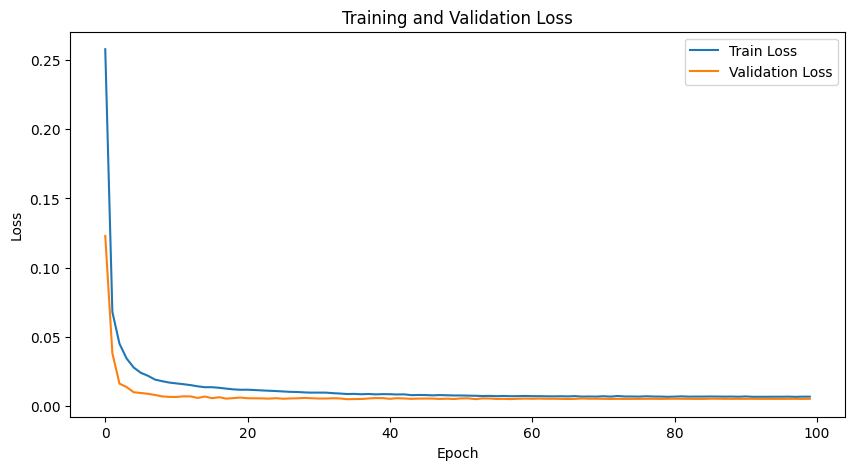

In [85]:
model_transformer_21_fixed = TransformerModel(
    input_size=n_features, 
    d_model=128, 
    nhead=8, 
    num_layers=2, 
    dim_feedforward=512, 
    output_size=n_future_21
)

optimizer_transformer_21_fixed = torch.optim.Adam(model_transformer_21_fixed.parameters(), lr=1e-4)
scheduler_transformer_21_fixed = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_21_fixed, mode='min', factor=0.5, patience=10)

model_transformer_21_fixed = train_model(
    model_transformer_21_fixed, 
    train_loader_21_corrected, 
    val_loader_21_corrected, 
    optimizer_transformer_21_fixed, 
    criterion, 
    scheduler_transformer_21_fixed, 
    num_epochs, 
    'Transformer_21_day'
)

Evaluating 5-day Transformer model...
Test RMSE: 5.4061
Test MAE: 5.4061
Evaluating 21-day Transformer model...
Test RMSE: 3.9987
Test MAE: 3.9987


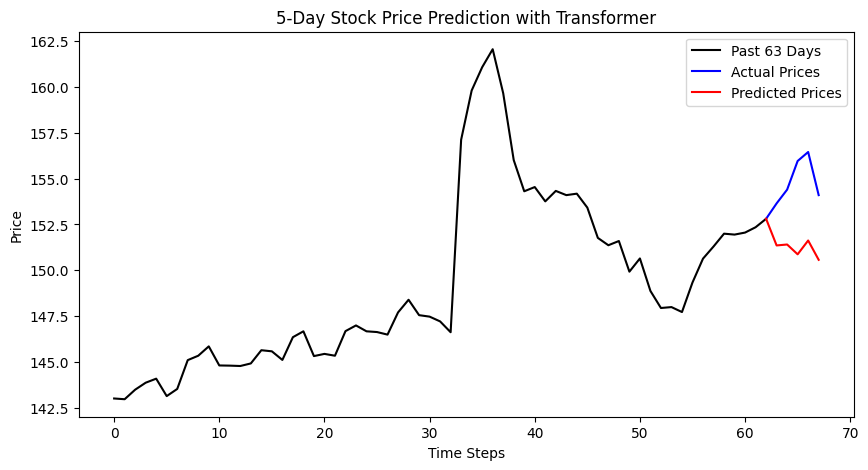

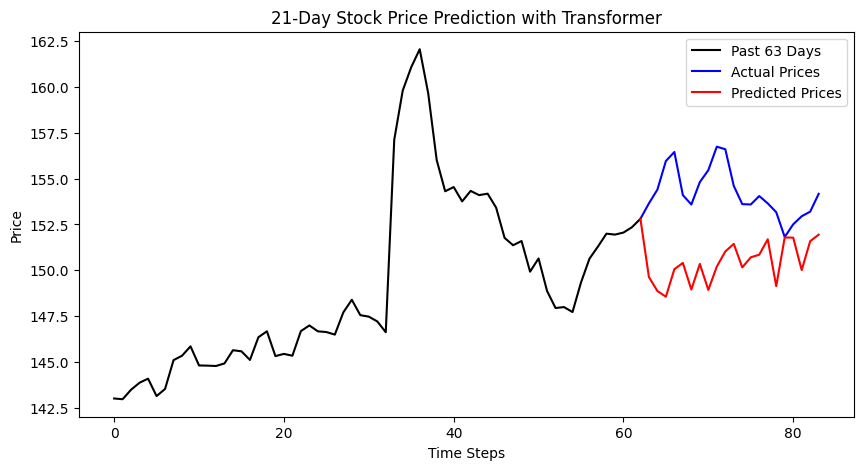

In [88]:
# Evaluate models
print("Evaluating 5-day Transformer model...")
simulated_prediction_transformer_5_fixed, y_test_transformer_5_fixed_real = evaluate_model(model_transformer_5_fixed, test_loader_5_corrected, y_scaler_5_corrected)
print("Evaluating 21-day Transformer model...")
simulated_prediction_transformer_21_fixed, y_test_transformer_21_fixed_real = evaluate_model(model_transformer_21_fixed, test_loader_21_corrected, y_scaler_21_corrected)

past_data = y[-63-21:-21].values  
x_past = np.arange(0, len(past_data))

true_future_5_days_transformer = y.iloc[-21:-16].values 
true_future_21_days_transformer = y.iloc[-21:].values   

# 5-day prediction data
true_5d_transformer = true_future_5_days_transformer
pred_5d_transformer = simulated_prediction_transformer_5_fixed.flatten()
x_future_5d_transformer = np.arange(len(past_data) - 1, len(past_data) + len(true_5d_transformer))

true_5d_transformer = np.insert(true_5d_transformer, 0, past_data[-1])
pred_5d_transformer = np.insert(pred_5d_transformer, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_5d_transformer, true_5d_transformer, label='Actual Prices', color='blue')
plt.plot(x_future_5d_transformer, pred_5d_transformer, label='Predicted Prices', color='red')
plt.title('5-Day Stock Price Prediction with Transformer')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()

# 21-day prediction data
true_21d_transformer = true_future_21_days_transformer
pred_21d_transformer = simulated_prediction_transformer_21_fixed.flatten()
x_future_21d_transformer = np.arange(len(past_data) - 1, len(past_data) + len(true_21d_transformer))

true_21d_transformer = np.insert(true_21d_transformer, 0, past_data[-1])
pred_21d_transformer = np.insert(pred_21d_transformer, 0, past_data[-1])

plt.figure(figsize=(10, 5))
plt.plot(x_past, past_data, label='Past 63 Days', color='black')
plt.plot(x_future_21d_transformer, true_21d_transformer, label='Actual Prices', color='blue')
plt.plot(x_future_21d_transformer, pred_21d_transformer, label='Predicted Prices', color='red')
plt.title('21-Day Stock Price Prediction with Transformer')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.show()